In [40]:
# Importing libraries and loading dataset
# Loading the dataset and check its basic structure by using shape and head fuctions

import pandas as pd
import numpy as np

df = pd.read_csv("paddydataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2789, 45)


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [41]:
# Cleaning column names
# Removing extra spaces and standardizing column names by  replacing " " with "_"

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

print("Cleaned column names:")
df.columns


Cleaned column names:


Index(['Hectares', 'Agriblock', 'Variety', 'Soil_Types', 'Seedrate(in_Kg)',
       'LP_Mainfield(in_Tonnes)', 'Nursery', 'Nursery_area_(Cents)',
       'LP_nurseryarea(in_Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb',
       'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days',
       'Pest_60Day(in_ml)', '30DRain(_in_mm)', '30DAI(in_mm)',
       '30_50DRain(_in_mm)', '30_50DAI(in_mm)', '51_70DRain(in_mm)',
       '51_70AI(in_mm)', '71_105DRain(in_mm)', '71_105DAI(in_mm)',
       'Min_temp_D1_D30', 'Max_temp_D1_D30', 'Min_temp_D31_D60',
       'Max_temp_D31_D60', 'Min_temp_D61_D90', 'Max_temp_D61_D90',
       'Min_temp_D91_D120', 'Max_temp_D91_D120',
       'Inst_Wind_Speed_D1_D30(in_Knots)', 'Inst_Wind_Speed_D31_D60(in_Knots)',
       'Inst_Wind_Speed_D61_D90(in_Knots)',
       'Inst_Wind_Speed_D91_D120(in_Knots)', 'Wind_Direction_D1_D30',
       'Wind_Direction_D31_D60', 'Wind_Direction_D61_D90',
       'Wind_Direction_D91_D120', 'Relative_Humidity_D1_D30',
       'Relative_Humid

In [42]:
# Check and remove duplicate rows
# Identify and remove duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 451
Shape after removing duplicates: (2338, 45)


In [43]:
# Check missing values
# Identify missing values in each column

missing_values = df.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

In [44]:
# Handling missing values

# Separating numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Filling numerical columns with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Filling categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values after treatment:", df.isnull().sum().sum())


Total missing values after treatment: 0


In [45]:
# Encode categorical variables into binary
# Convert categorical features into numerical form

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded successfully.")


Categorical columns encoded successfully.


In [46]:
# Final check after preprocessing dataset file
#TO Ensure dataset is clean

print("Final dataset shape:", df.shape)
df.head()


Final dataset shape: (2338, 45)


,Hectares,Agriblock,Variety,Soil_Types,Seedrate(in_Kg),LP_Mainfield(in_Tonnes),Nursery,Nursery_area_(Cents),LP_nurseryarea(in_Tonnes),DAP_20days,...,Wind_Direction_D1_D30,Wind_Direction_D31_D60,Wind_Direction_D61_D90,Wind_Direction_D91_D120,Relative_Humidity_D1_D30,Relative_Humidity_D31_D60,Relative_Humidity_D61_D90,Relative_Humidity_D91_D120,Trash(in_bundles),Paddy_yield(in_Kg)
0,6,1,0,0,150,75.0,0,120,6,240,...,4,3,2,5,72.0,78,88,85,540,35028
1,6,3,2,1,150,75.0,1,120,6,240,...,2,2,3,3,64.6,85,84,87,600,35412
2,6,4,1,0,150,75.0,0,120,6,240,...,1,1,1,4,85.0,96,84,79,600,36300
3,6,2,0,1,150,75.0,1,120,6,240,...,5,4,3,2,88.5,95,81,84,540,35016
4,6,5,2,0,150,75.0,0,120,6,240,...,3,3,4,1,72.7,91,83,81,600,34044


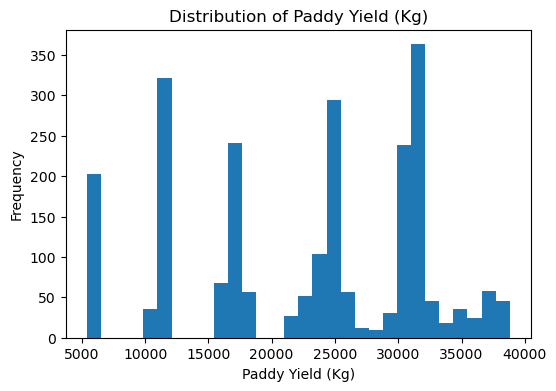

In [47]:
# Distribution of Paddy Yield to Understand how yield values are distributed by
# using histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Paddy_yield(in_Kg)"], bins=30)
plt.title("Distribution of Paddy Yield (Kg)")
plt.xlabel("Paddy Yield (Kg)")
plt.ylabel("Frequency")
plt.show()


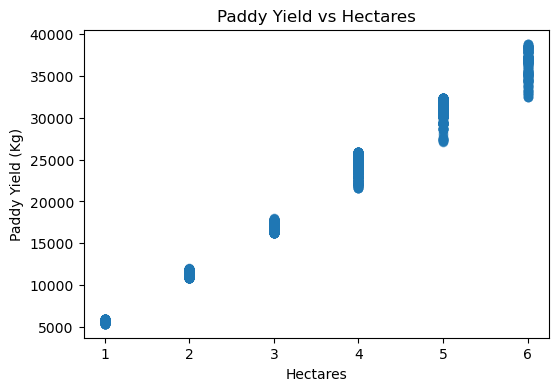

In [48]:
# Land area hectares vs Paddy yield
# Relationship between cultivated area and yield

plt.figure(figsize=(6,4))
plt.scatter(df["Hectares"], df["Paddy_yield(in_Kg)"], alpha=0.6)
plt.title("Paddy Yield vs Hectares")
plt.xlabel("Hectares")
plt.ylabel("Paddy Yield (Kg)")
plt.show()


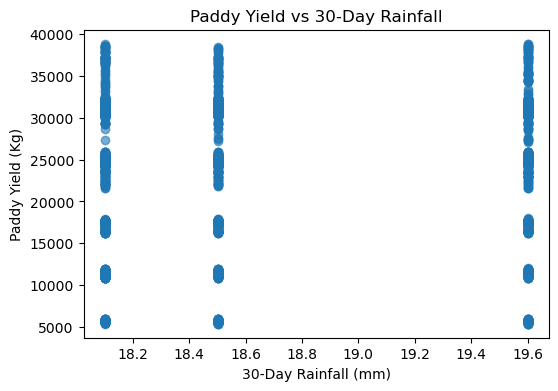

In [49]:
# Yield vs Rainfall

plt.figure(figsize=(6,4))
plt.scatter(df["30DRain(_in_mm)"], df["Paddy_yield(in_Kg)"], alpha=0.6)
plt.title("Paddy Yield vs 30-Day Rainfall")
plt.xlabel("30-Day Rainfall (mm)")
plt.ylabel("Paddy Yield (Kg)")
plt.show()




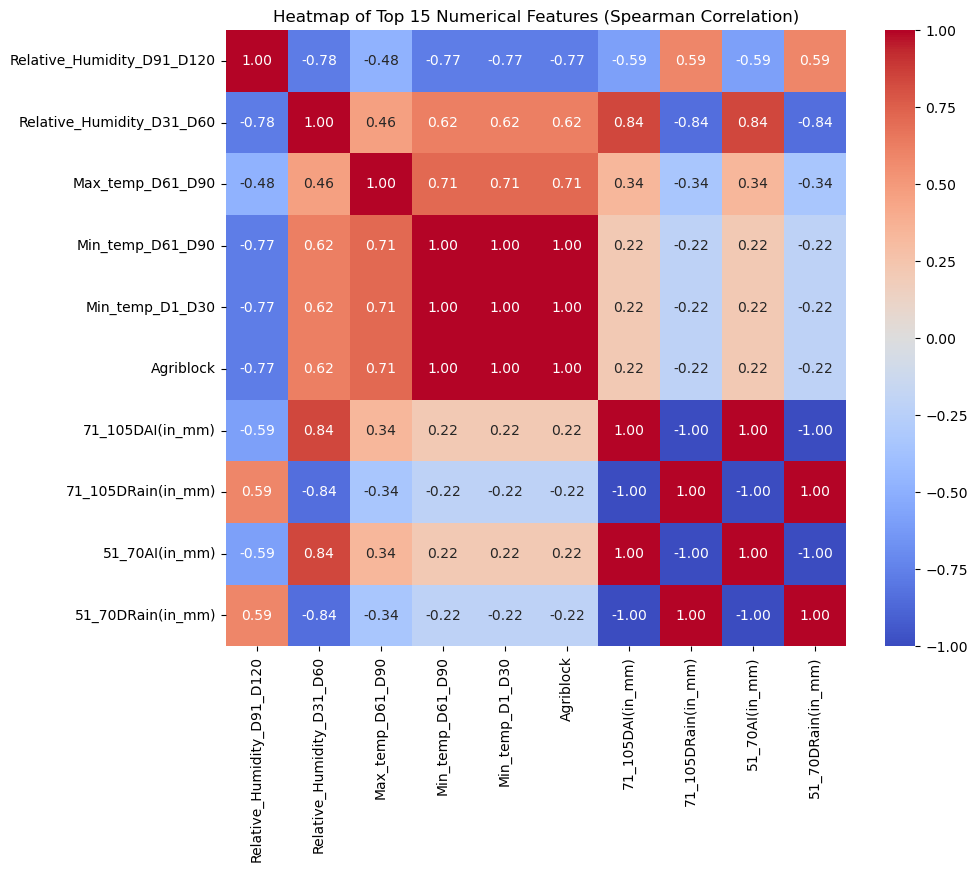

In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# select only numeric columns
num_df = df.select_dtypes(include=[np.number])

# compute spearman correlation
corr = num_df.corr(method="spearman")

# select top 10 columns most correlated with each other (high variance in correlation)
top10_cols = (
    corr.abs()
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .index
)

# subset correlation matrix
top10_corr = corr.loc[top10_cols, top10_cols]

# ploting heatmap
plt.figure(figsize=(10,8))
sns.heatmap(top10_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap of Top 15 Numerical Features (Spearman Correlation)")
plt.show()


In [51]:
# Target variable
target = "Paddy_yield(in_Kg)"

#     Removing leakage Columns to not used as predictors
leakage_cols = [
    "LP_Mainfield(in_Tonnes)",
    "LP_nurseryarea(in_Tonnes)"
]

X = df.drop(columns=leakage_cols + [target], errors="ignore")
y = df[target]

print("Initial feature count:", X.shape[1])


Initial feature count: 42


In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Train-test split used ONLY for estimating feature importance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Random Forest used only as a feature importance estimator
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Compute and sort feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

#Selecting and to print top 15 features
top_n = 15

top_features = importance.head(top_n)

print(f"Top {top_n} Features (Random Forest Feature Importance):\n")
for feature, value in top_features.items():
    print(f"{feature} : {value:.4f}")


Top 15 Features (Random Forest Feature Importance):

DAP_20days : 0.1094
Potassh_50Days : 0.1093
Weed28D_thiobencarb : 0.1072
Pest_60Day(in_ml) : 0.1068
Hectares : 0.1026
Seedrate(in_Kg) : 0.1016
Trash(in_bundles) : 0.1012
Urea_40Days : 0.0925
Nursery_area_(Cents) : 0.0883
Micronutrients_70Days : 0.0788
Nursery : 0.0005
Soil_Types : 0.0005
Variety : 0.0003
Max_temp_D61_D90 : 0.0001
Wind_Direction_D91_D120 : 0.0001


In [81]:
# Creating final feature set using the selected top features (for regression models later)

selected_features = top_features.index.tolist()
X_selected = X[selected_features]

print("Selected features for regression modeling:\n")
for col in selected_features:
    print(">", col)

print("\nX selected shape:", X_selected.shape)


Selected features for regression modeling:

> DAP_20days
> Potassh_50Days
> Weed28D_thiobencarb
> Pest_60Day(in_ml)
> Hectares
> Seedrate(in_Kg)
> Trash(in_bundles)
> Urea_40Days
> Nursery_area_(Cents)
> Micronutrients_70Days
> Nursery
> Soil_Types
> Variety
> Max_temp_D61_D90
> Wind_Direction_D91_D120

X selected shape: (2338, 15)


In [54]:
# Train, Test split data for regression modeling

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (1870, 15)
Testing shape: (468, 15)


In [55]:
# Feature scaling  for linear & distance based regressors

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")


Feature scaling completed.


In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf_reg = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)

print("Random Forest Regressor Results:")
print("R2 Score :", r2_score(y_test, y_pred_rf))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Men Absolute Error :", mean_absolute_error(y_test, y_pred_rf))


Random Forest Regressor Results:
R2 Score : 0.9891074036240546
Root Mean Squared Error: 965.6680061003278
Men Absolute Error : 693.282072774512
